In [3]:
import math
from pathlib import Path
from typing import Iterable, List, Sequence, Tuple, Union

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


DATA_PATH = Path("airports.csv")
OUT_DIR = Path("outputs")



def is_us_airport(lat: float, lon: float) -> bool:
#check if airport is us
    if pd.isna(lat) or pd.isna(lon):
        return False

    contiguous = (24.0 <= lat <= 50.5) and (-125.0 <= lon <= -66.0)

    # Alaska
    alaska = (51.0 <= lat <= 72.5) and (-170.0 <= lon <= -130.0)

    # Hawaii
    hawaii = (18.0 <= lat <= 23.5) and (-161.0 <= lon <= -154.0)

    return contiguous or alaska or hawaii


def get_jfk(df_airports: pd.DataFrame) -> pd.Series:
#Return the row for JFK from the airports table
    jfk = df_airports.loc[df_airports["faa"].astype(str).str.upper() == "JFK"]
    if jfk.empty:
        raise ValueError("Could not find JFK in airports.csv (faa == 'JFK').")
    return jfk.iloc[0]


def ensure_out_dir() -> None:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
# <- check that output dir exist lol

def save_html(fig: go.Figure, name: str) -> Path:
#Save Plotly figure to HTML
    ensure_out_dir()
    out_path = OUT_DIR / f"{name}.html"
    fig.write_html(out_path, include_plotlyjs="cdn")
    return out_path



def plot_all_airports_world(df: pd.DataFrame, color_by_altitude: bool = False) -> go.Figure:
#World map with points for all airports
    color = "alt" if color_by_altitude else None
    fig = px.scatter_geo(
        df,
        lat="lat",
        lon="lon",
        hover_name="name",
        hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
        color=color,
        title="All airports (world map)" + (" — color coded by altitude" if color_by_altitude else ""),
    )
    fig.update_geos(showland=True)
    fig.update_layout(margin=dict(l=10, r=10, t=60, b=10))
    return fig


def plot_airports_us_and_outside(df: pd.DataFrame, color_by_altitude: bool = False) -> Tuple[go.Figure, go.Figure]:
    #Identify airports outside the US
     # Map of outside-US airports world map
      # Map of US-only airports
    df = df.copy()
    df["in_us"] = df.apply(lambda r: is_us_airport(r["lat"], r["lon"]), axis=1)

    df_us = df[df["in_us"]].copy()
    df_out = df[~df["in_us"]].copy()

    color = "alt" if color_by_altitude else None

    fig_out = px.scatter_geo(
        df_out,
        lat="lat",
        lon="lon",
        hover_name="name",
        hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
        color=color,
        title="Airports outside the US (heuristic from lat/lon)" + (" — color coded by altitude" if color_by_altitude else ""),
    )
    fig_out.update_geos(showland=True)
    fig_out.update_layout(margin=dict(l=10, r=10, t=60, b=10))

    fig_us = px.scatter_geo(
        df_us,
        lat="lat",
        lon="lon",
        hover_name="name",
        hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
        color=color,
        scope="usa",
        title="Airports in the US (heuristic from lat/lon)" + (" — color coded by altitude" if color_by_altitude else ""),
    )
    fig_us.update_layout(margin=dict(l=10, r=10, t=60, b=10))

    return fig_out, fig_us


def _route_lines_trace(
    origin_lat: float, origin_lon: float, dest_lats: Sequence[float], dest_lons: Sequence[float]
) -> go.Scattergeo:

    #Create a single Scattergeo trace containing multiple independent line segments.
    #Plotly separates segments with None.

    lats: List[Union[float, None]] = []
    lons: List[Union[float, None]] = []
    for lat, lon in zip(dest_lats, dest_lons):
        lats.extend([origin_lat, lat, None])
        lons.extend([origin_lon, lon, None])

    return go.Scattergeo(
        lat=lats,
        lon=lons,
        mode="lines",
        line=dict(width=2),
        hoverinfo="skip",
        name="Routes",
    )


def plot_route_from_nyc(df: pd.DataFrame, faa: str, us_only_if_us: bool = True) -> go.Figure:

    #function that takes an FAA abbreviation and plots a world map and a line from NYC (JFK) to that airport

    #Note: If the airport is in the US, make a US-only map (scope='usa') when us_only_if_us=True.

    df = df.copy()
    faa = str(faa).upper()

    jfk = get_jfk(df)
    target = df.loc[df["faa"].astype(str).str.upper() == faa]
    if target.empty:
        raise ValueError(f"FAA code '{faa}' not found in airports.csv.")
    target = target.iloc[0]

    in_us = is_us_airport(float(target["lat"]), float(target["lon"]))
    use_usa_scope = bool(us_only_if_us and in_us)

    if use_usa_scope:
        base = px.scatter_geo(
            df,
            lat="lat",
            lon="lon",
            hover_name="name",
            hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
            scope="usa",
            title=f"Route from NYC (JFK) to {faa} — US-only scope",
        )
    else:
        base = px.scatter_geo(
            df,
            lat="lat",
            lon="lon",
            hover_name="name",
            hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
            title=f"Route from NYC (JFK) to {faa} — world scope",
        )
        base.update_geos(showland=True)

    # Routeline
    line = _route_lines_trace(float(jfk["lat"]), float(jfk["lon"]), [float(target["lat"])], [float(target["lon"])])
    base.add_trace(line)

    # points
    base.add_trace(
        go.Scattergeo(
            lat=[float(jfk["lat"])],
            lon=[float(jfk["lon"])],
            mode="markers",
            marker=dict(size=10),
            name="JFK",
            text=["JFK (NYC)"],
            hoverinfo="text",
        )
    )
    base.add_trace(
        go.Scattergeo(
            lat=[float(target["lat"])],
            lon=[float(target["lon"])],
            mode="markers",
            marker=dict(size=10),
            name=faa,
            text=[f"{faa}: {target['name']}"],
            hoverinfo="text",
        )
    )

    base.update_layout(margin=dict(l=10, r=10, t=60, b=10))
    return base


def plot_routes_from_nyc(df: pd.DataFrame, faas: Sequence[str], us_only_if_us: bool = False) -> go.Figure:

    df = df.copy()
    faas = [str(x).upper() for x in faas]

    jfk = get_jfk(df)
    targets = df[df["faa"].astype(str).str.upper().isin(faas)].copy()

    missing = sorted(set(faas) - set(targets["faa"].astype(str).str.upper()))
    if missing:
        raise ValueError(f"FAA codes not found in airports.csv: {missing}")

    targets["in_us"] = targets.apply(lambda r: is_us_airport(r["lat"], r["lon"]), axis=1)

    use_usa_scope = bool(us_only_if_us and targets["in_us"].all())

    if use_usa_scope:
        fig = px.scatter_geo(
            df,
            lat="lat",
            lon="lon",
            hover_name="name",
            hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
            scope="usa",
            title=f"Routes from NYC (JFK) to {len(faas)} airports — US-only scope",
        )
    else:
        fig = px.scatter_geo(
            df,
            lat="lat",
            lon="lon",
            hover_name="name",
            hover_data={"faa": True, "alt": True, "tzone": True, "lat": False, "lon": False},
            title=f"Routes from NYC (JFK) to {len(faas)} airports — world scope",
        )
        fig.update_geos(showland=True)

    #multi-segment line trace
    line = _route_lines_trace(float(jfk["lat"]), float(jfk["lon"]), targets["lat"].astype(float), targets["lon"].astype(float))
    fig.add_trace(line)

    #JFK marker
    fig.add_trace(
        go.Scattergeo(
            lat=[float(jfk["lat"])],
            lon=[float(jfk["lon"])],
            mode="markers",
            marker=dict(size=10),
            name="JFK",
            text=["JFK (NYC)"],
            hoverinfo="text",
        )
    )

    fig.update_layout(margin=dict(l=10, r=10, t=60, b=10))
    return fig


def euclidean_distance_deg(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    return math.sqrt((lat2 - lat1) ** 2 + (lon2 - lon1) ** 2)


def geodesic_distance_km(lat1: float, lon1: float, lat2: float, lon2: float, R_km: float = 6371.0) -> float:

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    lam1 = math.radians(lon1)
    lam2 = math.radians(lon2)

    dphi = phi2 - phi1
    dlam = lam2 - lam1
    phi_m = 0.5 * (phi1 + phi2)

    term1 = 2.0 * math.sin(dphi / 2.0) * math.cos(dlam / 2.0)
    term2 = 2.0 * math.cos(phi_m) * math.sin(dlam / 2.0)

    return R_km * math.sqrt(term1 * term1 + term2 * term2)


def plot_distance_distributions(df: pd.DataFrame) -> Tuple[pd.DataFrame, go.Figure, go.Figure]:

    df = df.copy()
    jfk = get_jfk(df)

    lat0 = float(jfk["lat"])
    lon0 = float(jfk["lon"])

    df["dist_euclid_deg"] = df.apply(lambda r: euclidean_distance_deg(lat0, lon0, float(r["lat"]), float(r["lon"])), axis=1)
    df["dist_geodesic_km"] = df.apply(lambda r: geodesic_distance_km(lat0, lon0, float(r["lat"]), float(r["lon"])), axis=1)

    # Basic stats
    stats = df[["dist_euclid_deg", "dist_geodesic_km"]].describe(percentiles=[0.25, 0.5, 0.75]).T
    stats = stats.rename(columns={"50%": "median"})

    fig_e = px.histogram(
        df,
        x="dist_euclid_deg",
        nbins=50,
        title="Distribution of Euclidean distances from JFK (in degree space)",
    )
    fig_e.update_layout(margin=dict(l=10, r=10, t=60, b=10))

    fig_g = px.histogram(
        df,
        x="dist_geodesic_km",
        nbins=50,
        title="Distribution of geodesic distances from JFK (km, R=6371)",
    )
    fig_g.update_layout(margin=dict(l=10, r=10, t=60, b=10))

    return stats, fig_e, fig_g


def analyze_timezones(df: pd.DataFrame) -> go.Figure:

    counts = (
        df.assign(tzone=df["tzone"].fillna("Unknown"))
          .groupby("tzone", as_index=False)
          .size()
          .sort_values("size", ascending=False)
    )

    fig = px.bar(
        counts,
        x="tzone",
        y="size",
        title="Time zones — number of airports per time zone (proxy for 'relative amount')",
    )
    fig.update_layout(xaxis_title="Time zone", yaxis_title="Number of airports", margin=dict(l=10, r=10, t=60, b=10))
    return fig



def main() -> None:
    # Load
    df = pd.read_csv(DATA_PATH)

    print("Loaded airports.csv")
    print(df.head())
    print(f"Rows: {len(df):,}  Columns: {list(df.columns)}")

    # Task 1
    fig_all = plot_all_airports_world(df, color_by_altitude=False)
    save_html(fig_all, "01_all_airports_world")

    # Extra color coded by altitude
    fig_all_alt = plot_all_airports_world(df, color_by_altitude=True)
    save_html(fig_all_alt, "01b_all_airports_world_altitude")

    # 2 outside US + US-only map
    fig_out, fig_us = plot_airports_us_and_outside(df, color_by_altitude=False)
    save_html(fig_out, "02_airports_outside_us")
    save_html(fig_us, "03_airports_us_only")

    # Extra altitude coloring
    fig_out_alt, fig_us_alt = plot_airports_us_and_outside(df, color_by_altitude=True)
    save_html(fig_out_alt, "02b_airports_outside_us_altitude")
    save_html(fig_us_alt, "03b_airports_us_only_altitude")

    # 3 function route map for one FAA code
    example_faa = "LAX"
    fig_route = plot_route_from_nyc(df, example_faa, us_only_if_us=True)
    save_html(fig_route, f"04_route_JFK_to_{example_faa}")

    #4 routes to multiple FAA codes (example)
    example_faas = ["LAX", "ORD", "MIA", "SEA"]
    fig_routes = plot_routes_from_nyc(df, example_faas, us_only_if_us=False)
    save_html(fig_routes, "05_routes_JFK_to_multiple")

    # 5 Euclidean distance distribution from JFK
    stats, fig_euclid, fig_geo = plot_distance_distributions(df)
    print("\nDistance summary statistics (from JFK):")
    print(stats)

    save_html(fig_euclid, "06_distribution_euclidean_degree_space")
    save_html(fig_geo, "07_distribution_geodesic_km")

    # 6 time zones analysis
    fig_tz = analyze_timezones(df)
    save_html(fig_tz, "08_timezones_airport_counts_proxy")

    print(f"\nSaved all interactive plots to: {OUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

Loaded airports.csv
   faa                                 name        lat         lon   alt   tz  \
0  AAF        Apalachicola Regional Airport  29.727501  -85.027496    20 -5.0   
1  AAP                       Andrau Airpark  29.722500  -95.588303    79 -6.0   
2  ABE  Lehigh Valley International Airport  40.652100  -75.440804   393 -5.0   
3  ABI             Abilene Regional Airport  32.411301  -99.681900  1791 -6.0   
4  ABL                       Ambler Airport  67.106300 -157.856989   334 -9.0   

  dst              tzone  
0   A   America/New_York  
1   A    America/Chicago  
2   A   America/New_York  
3   A    America/Chicago  
4   A  America/Anchorage  
Rows: 1,251  Columns: ['faa', 'name', 'lat', 'lon', 'alt', 'tz', 'dst', 'tzone']

Distance summary statistics (from JFK):
                   count         mean          std  min          25%  \
dist_euclid_deg   1251.0    32.111609    27.282391  0.0    12.719514   
dist_geodesic_km  1251.0  2519.394448  1778.619463  0.0  1164.641

             Id          Class
0  1.503960e+09     Heavy User
1  1.624580e+09     Heavy User
2  1.644430e+09     Light User
3  1.844505e+09  Moderate User
4  1.927972e+09  Moderate User
Class
Moderate User    22
Light User        9
Heavy User        4
Name: count, dtype: int64
             Id         logId            start_time              end_time  \
0  1.503960e+09  1.111492e+10  3/13/2016 2:39:30 AM  3/13/2016 9:44:30 AM   
1  1.503960e+09  1.112634e+10  3/14/2016 1:32:00 AM  3/14/2016 7:57:00 AM   
2  1.503960e+09  1.113497e+10  3/15/2016 2:36:00 AM  3/15/2016 8:10:00 AM   
3  1.503960e+09  1.114220e+10  3/16/2016 3:12:00 AM  3/16/2016 8:14:00 AM   
4  1.503960e+09  1.114220e+10  3/16/2016 7:43:00 PM  3/16/2016 8:45:00 PM   

   sleep_minutes  
0            426  
1            386  
2            335  
3            303  
4             63  
             Id        date  total_active_minutes
0  1.503960e+09  2016-03-25                   250
1  1.503960e+09  2016-03-26                  

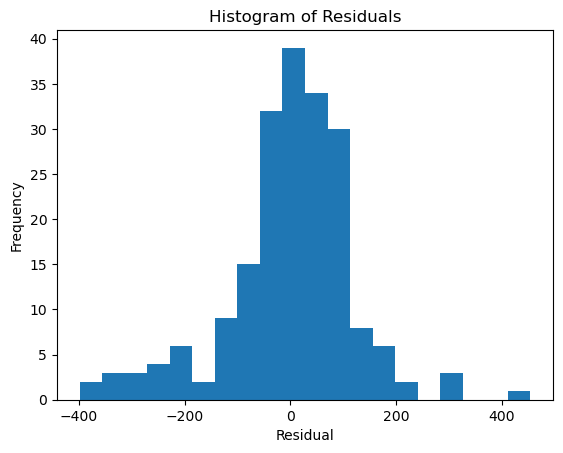

  time_block   avg_steps
0        0-4   20.708231
1        4-8  105.642066
2       8-12  421.251057
3      12-16  460.872960
4      16-20  483.862893
5      20-24  234.167929
  time_block  avg_calories
0        0-4     69.423812
1        4-8     79.285609
2       8-12    104.735009
3      12-16    109.816972
4      16-20    113.513962
5      20-24     89.668182
  time_block  avg_sleep_minutes
0        0-4        3897.000000
1        4-8        3362.095238
2       8-12         770.700000
3      12-16         194.250000
4      16-20         154.384615
5      20-24        1318.300000


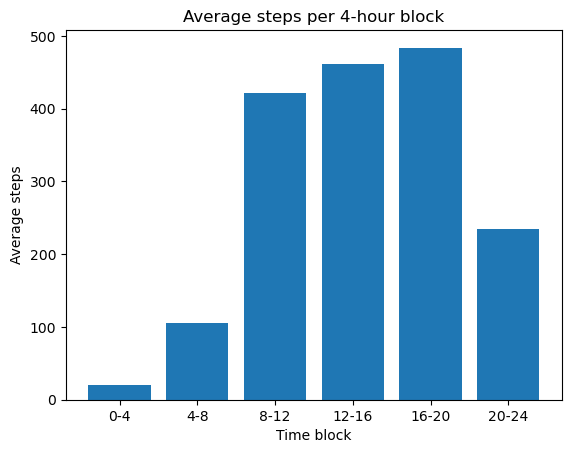

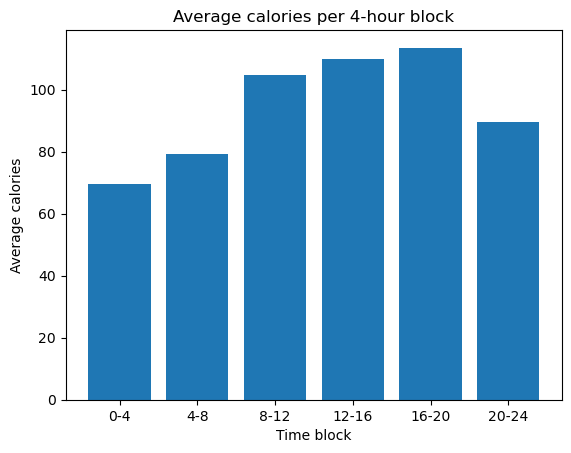

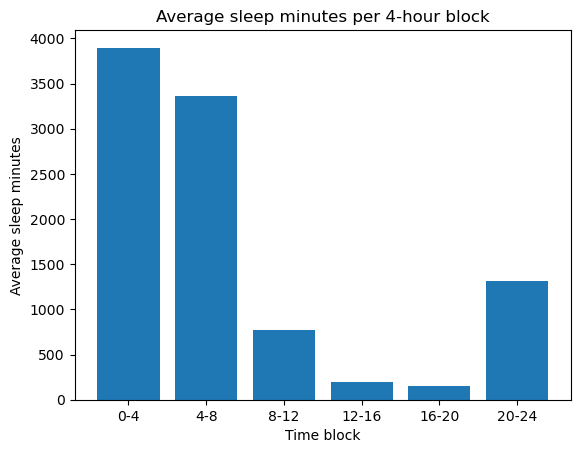

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd

# here i used sqlite3 to connect to the database. and using the SQL query we can access parts of the database so we don't have to load everything

con = sqlite3.connect("fights_database.db")

df_class = pd.read_sql("""
WITH counts AS (
    SELECT 
        Id,
        COUNT(*) AS n_days
    FROM daily_activity
    GROUP BY Id
)
SELECT
    Id,
    CASE
        WHEN n_days <= 10 THEN 'Light User'
        WHEN n_days <= 15 THEN 'Moderate User'
        ELSE 'Heavy User'
    END AS Class
FROM counts
ORDER BY Id;
""", con)

print(df_class.head())
print(df_class["Class"].value_counts())

# now i start investigating, first part the sleep duration for each sleep moment

sleep_sessions = pd.read_sql("""
SELECT
    Id,
    logId,
    MIN(date) AS start_time,
    MAX(date) AS end_time,
    COUNT(*) AS sleep_minutes
FROM minute_sleep
GROUP BY Id, logId
ORDER BY Id, start_time;
""", con)

print(sleep_sessions.head())

# part two: is sleep duration related to active minutes? and the total sleep minutes per day

active_by_day = pd.read_sql("""
SELECT
    Id,
    (
      substr(ActivityDate, instr(ActivityDate, '/') + instr(substr(ActivityDate, instr(ActivityDate, '/')+1), '/') + 1, 4)
      || '-' ||
      CASE
        WHEN instr(ActivityDate, '/') = 2 THEN '0' || substr(ActivityDate, 1, 1)
        ELSE substr(ActivityDate, 1, 2)
      END
      || '-' ||
      CASE
        WHEN instr(substr(ActivityDate, instr(ActivityDate, '/')+1), '/') = 2 THEN '0' || substr(ActivityDate, instr(ActivityDate, '/')+1, 1)
        ELSE substr(ActivityDate, instr(ActivityDate, '/')+1, 2)
      END
    ) AS date,
    (VeryActiveMinutes + FairlyActiveMinutes + LightlyActiveMinutes) AS total_active_minutes
FROM daily_activity
ORDER BY Id, date;
""", con)

print(active_by_day.head())

sleep_by_day = pd.read_sql("""
SELECT
    Id,
    (
      substr(date, instr(date, '/') + instr(substr(date, instr(date, '/')+1), '/') + 1, 4)
      || '-' ||
      printf('%02d', CAST(substr(date, 1, instr(date, '/')-1) AS INTEGER))
      || '-' ||
      printf('%02d', CAST(substr(date,
              instr(date, '/')+1,
              instr(substr(date, instr(date, '/')+1), '/')-1) AS INTEGER))
    ) AS date,
    COUNT(*) AS sleep_minutes
FROM minute_sleep
GROUP BY
    Id,
    (
      substr(date, instr(date, '/') + instr(substr(date, instr(date, '/')+1), '/') + 1, 4)
      || '-' ||
      printf('%02d', CAST(substr(date, 1, instr(date, '/')-1) AS INTEGER))
      || '-' ||
      printf('%02d', CAST(substr(date,
              instr(date, '/')+1,
              instr(substr(date, instr(date, '/')+1), '/')-1) AS INTEGER))
    )
ORDER BY Id, date;
""", con)

print(sleep_by_day.head())

print(sleep_by_day.head())
print(len(sleep_by_day))

# we need to join active_by_day with sleep_by_day

df_combined = active_by_day.merge(sleep_by_day, on=["Id", "date"], how="inner")
print(df_combined.head())
print("Rows:", len(df_combined))


# now a regression sleep minutes = a * b*(total active minutes). if b is postive for instance, more active = more sleep

import statsmodels.api as sm

X = sm.add_constant(df_combined["total_active_minutes"])
y = df_combined["sleep_minutes"]

model = sm.OLS(y, X).fit()
print(model.summary())

# there is no significant linear relationship between total active minutes and sleep duration

# part 3: analyse relationship between the amount of sedentary activity and the sleep duration
# we first define sedentary minutes per day 

sedentary_by_day = pd.read_sql("""
SELECT
    Id,
    (
      substr(ActivityDate, instr(ActivityDate, '/') + instr(substr(ActivityDate, instr(ActivityDate, '/')+1), '/') + 1, 4)
      || '-' ||
      printf('%02d', CAST(substr(ActivityDate, 1, instr(ActivityDate, '/')-1) AS INTEGER))
      || '-' ||
      printf('%02d', CAST(substr(ActivityDate,
              instr(ActivityDate, '/')+1,
              instr(substr(ActivityDate, instr(ActivityDate, '/')+1), '/')-1) AS INTEGER))
    ) AS date,
    SedentaryMinutes AS sedentary_minutes
FROM daily_activity;
""", con)

print(sedentary_by_day.head())

# now join it with sleep

df_sedentary = sedentary_by_day.merge(
    sleep_by_day,
    on=["Id", "date"],
    how="inner"
)

print(df_sedentary.head())
print("Rows:", len(df_sedentary))

# and now i run the regression: sleep minutes = betah(0) + betah(1)*(sedentary minutes)

import statsmodels.api as sm

X = sm.add_constant(df_sedentary["sedentary_minutes"])
y = df_sedentary["sleep_minutes"]

model_sed = sm.OLS(y, X).fit()
print(model_sed.summary())

# regression assumes residual is normally distributed so i also want to observe actual sleep - predicted sleep to confirm if it is normal

import matplotlib.pyplot as plt

residuals = model_sed.resid

plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# so on average, an additional minute of sedentary activity means a decrease of approx 0.46 minutes of sleep. 
# it also shows that  35.8% of the variation in sleep duration (R^2 = 0.358) which we find moderate
# also with the digram we can see that it is reliable 

# next analysation part 4: avg of different factors in 4 hour day blocks
# steps per 4 hour:

steps_blocks = pd.read_sql("""
WITH parsed AS (
  SELECT
    StepTotal,
    CASE
      -- hour in 12h clock as integer
      WHEN ActivityHour LIKE '%AM' AND CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER) = 12
        THEN 0
      WHEN ActivityHour LIKE '%PM' AND CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER) < 12
        THEN CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER) + 12
      ELSE CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER)
    END AS hour24
  FROM hourly_steps
),
blocked AS (
  SELECT
    CASE
      WHEN hour24 BETWEEN 0 AND 3  THEN '0-4'
      WHEN hour24 BETWEEN 4 AND 7  THEN '4-8'
      WHEN hour24 BETWEEN 8 AND 11 THEN '8-12'
      WHEN hour24 BETWEEN 12 AND 15 THEN '12-16'
      WHEN hour24 BETWEEN 16 AND 19 THEN '16-20'
      ELSE '20-24'
    END AS time_block,
    StepTotal
  FROM parsed
)
SELECT time_block, AVG(StepTotal) AS avg_steps
FROM blocked
GROUP BY time_block
ORDER BY
  CASE time_block
    WHEN '0-4' THEN 1 WHEN '4-8' THEN 2 WHEN '8-12' THEN 3
    WHEN '12-16' THEN 4 WHEN '16-20' THEN 5 ELSE 6
  END;
""", con)

print(steps_blocks)


# calories per 4 hours:

calories_blocks = pd.read_sql("""
WITH parsed AS (
  SELECT
    Calories,
    CASE
      WHEN ActivityHour LIKE '%AM' AND CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER) = 12
        THEN 0
      WHEN ActivityHour LIKE '%PM' AND CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER) < 12
        THEN CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER) + 12
      ELSE CAST(substr(ActivityHour, instr(ActivityHour,' ') + 1,
           instr(substr(ActivityHour, instr(ActivityHour,' ')+1), ':') - 1) AS INTEGER)
    END AS hour24
  FROM hourly_calories
),
blocked AS (
  SELECT
    CASE
      WHEN hour24 BETWEEN 0 AND 3  THEN '0-4'
      WHEN hour24 BETWEEN 4 AND 7  THEN '4-8'
      WHEN hour24 BETWEEN 8 AND 11 THEN '8-12'
      WHEN hour24 BETWEEN 12 AND 15 THEN '12-16'
      WHEN hour24 BETWEEN 16 AND 19 THEN '16-20'
      ELSE '20-24'
    END AS time_block,
    Calories
  FROM parsed
)
SELECT time_block, AVG(Calories) AS avg_calories
FROM blocked
GROUP BY time_block
ORDER BY
  CASE time_block
    WHEN '0-4' THEN 1 WHEN '4-8' THEN 2 WHEN '8-12' THEN 3
    WHEN '12-16' THEN 4 WHEN '16-20' THEN 5 ELSE 6
  END;
""", con)

print(calories_blocks)


# sleep minutes per 4 hours:

sleep_blocks = pd.read_sql("""
WITH parsed AS (
  SELECT
    Id,
    CASE
      WHEN date LIKE '%AM' AND CAST(substr(date, instr(date,' ') + 1,
           instr(substr(date, instr(date,' ')+1), ':') - 1) AS INTEGER) = 12
        THEN 0
      WHEN date LIKE '%PM' AND CAST(substr(date, instr(date,' ') + 1,
           instr(substr(date, instr(date,' ')+1), ':') - 1) AS INTEGER) < 12
        THEN CAST(substr(date, instr(date,' ') + 1,
           instr(substr(date, instr(date,' ')+1), ':') - 1) AS INTEGER) + 12
      ELSE CAST(substr(date, instr(date,' ') + 1,
           instr(substr(date, instr(date,' ')+1), ':') - 1) AS INTEGER)
    END AS hour24
  FROM minute_sleep
),
blocked AS (
  SELECT
    Id,
    CASE
      WHEN hour24 BETWEEN 0 AND 3  THEN '0-4'
      WHEN hour24 BETWEEN 4 AND 7  THEN '4-8'
      WHEN hour24 BETWEEN 8 AND 11 THEN '8-12'
      WHEN hour24 BETWEEN 12 AND 15 THEN '12-16'
      WHEN hour24 BETWEEN 16 AND 19 THEN '16-20'
      ELSE '20-24'
    END AS time_block
  FROM parsed
)
SELECT
  time_block,
  1.0 * COUNT(*) / COUNT(DISTINCT Id) AS avg_sleep_minutes
FROM blocked
GROUP BY time_block
ORDER BY
  CASE time_block
    WHEN '0-4' THEN 1 WHEN '4-8' THEN 2 WHEN '8-12' THEN 3
    WHEN '12-16' THEN 4 WHEN '16-20' THEN 5 ELSE 6
  END;
""", con)

print(sleep_blocks)



# now visualize all features more clearly 

import matplotlib.pyplot as plt

plt.bar(steps_blocks["time_block"], steps_blocks["avg_steps"])
plt.title("Average steps per 4-hour block")
plt.xlabel("Time block")
plt.ylabel("Average steps")
plt.show()

plt.bar(calories_blocks["time_block"], calories_blocks["avg_calories"])
plt.title("Average calories per 4-hour block")
plt.xlabel("Time block")
plt.ylabel("Average calories")
plt.show()

plt.bar(sleep_blocks["time_block"], sleep_blocks["avg_sleep_minutes"])
plt.title("Average sleep minutes per 4-hour block")
plt.xlabel("Time block")
plt.ylabel("Average sleep minutes")
plt.show()





Using Id: 2022484408


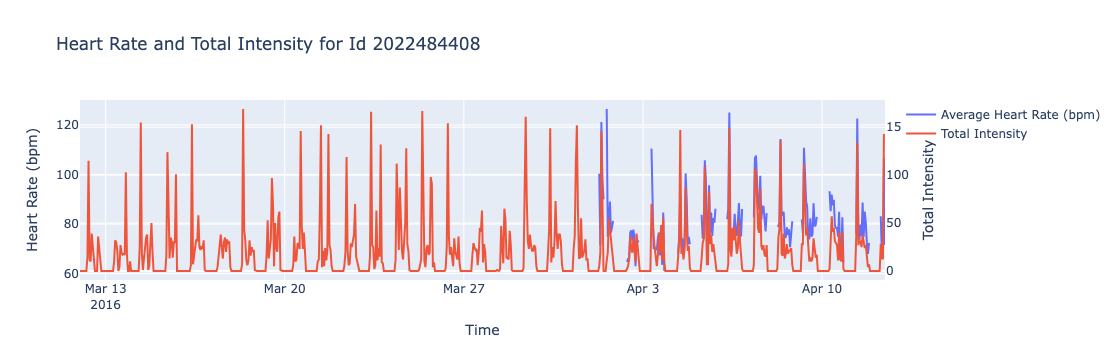

In [5]:
import pandas as pd
import plotly.graph_objects as go

hr_ids = pd.read_sql("""
    SELECT Id
    FROM heart_rate
    GROUP BY Id
    LIMIT 1;
""", con)

valid_id = int(hr_ids["Id"].iloc[0])
print("Using Id:", valid_id)

def plot_heart_and_intensity(con, user_id):
    heart = pd.read_sql("""
        SELECT Id, Time, Value
        FROM heart_rate
        WHERE CAST(Id AS INTEGER) = ?;
    """, con, params=(user_id,))

    intensity = pd.read_sql("""
        SELECT Id, ActivityHour, TotalIntensity
        FROM hourly_intensity
        WHERE CAST(Id AS INTEGER) = ?;
    """, con, params=(user_id,))

    if heart.empty:
        print("No heart rate data for this Id.")
        return None
    if intensity.empty:
        print("No intensity data for this Id.")
        return None

    dt_format = "%m/%d/%Y %I:%M:%S %p"

    heart["Time"] = pd.to_datetime(heart["Time"], format=dt_format)
    intensity["ActivityHour"] = pd.to_datetime(intensity["ActivityHour"], format=dt_format)

    # hourly average heart rate
    heart["hour"] = heart["Time"].dt.floor("h")
    heart_hourly = (heart.groupby("hour")["Value"]
                         .mean()
                         .reset_index()
                         .rename(columns={"Value": "avg_heart_rate"}))

    # intensity already hourly
    intensity = intensity.rename(columns={"ActivityHour": "hour"})

    # merge (outer keeps all hours even if one series missing)
    df = pd.merge(
        heart_hourly,
        intensity[["hour", "TotalIntensity"]],
        on="hour",
        how="outer"
    ).sort_values("hour")

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df["hour"], y=df["avg_heart_rate"],
        mode="lines", name="Average Heart Rate (bpm)"
    ))
    fig.add_trace(go.Scatter(
        x=df["hour"], y=df["TotalIntensity"],
        mode="lines", name="Total Intensity", yaxis="y2"
    ))

    fig.update_layout(
        title=f"Heart Rate and Total Intensity for Id {int(user_id)}",
        xaxis_title="Time",
        yaxis=dict(title="Heart Rate (bpm)"),
        yaxis2=dict(title="Total Intensity", overlaying="y", side="right"),
    )
    return fig

fig = plot_heart_and_intensity(con, valid_id)

if fig is not None:
    fig.show()



In [6]:
# last analisis they ask

df_dates = pd.read_sql("SELECT ActivityDate FROM daily_activity;", con)
df_dates["date"] = pd.to_datetime(df_dates["ActivityDate"], format="%m/%d/%Y")

print(df_dates["date"].min(), df_dates["date"].max())


2016-03-12 00:00:00 2016-04-12 00:00:00


               name    datetime  tempmax  tempmin  temp  feelslikemax  \
0  Chicago, IL, USA  2016-03-07     62.0     47.0  54.8          62.0   
1  Chicago, IL, USA  2016-03-08     71.1     59.0  63.9          71.1   
2  Chicago, IL, USA  2016-03-09     63.7     53.8  59.9          63.7   
3  Chicago, IL, USA  2016-03-10     52.1     42.1  46.9          52.1   
4  Chicago, IL, USA  2016-03-11     52.9     37.8  42.7          52.9   

   feelslikemin  feelslike   dew  humidity  ...  solarenergy  uvindex  \
0          41.3       53.0  41.2      60.2  ...         13.3        5   
1          59.0       63.9  50.4      62.1  ...         12.0        7   
2          53.8       59.9  53.2      78.7  ...          6.6        4   
3          37.3       43.2  37.5      69.9  ...          7.0        4   
4          34.2       39.9  32.4      68.1  ...         17.9        7   

   severerisk              sunrise               sunset  moonphase  \
0         NaN  2016-03-07T06:14:50  2016-03-07T17:48

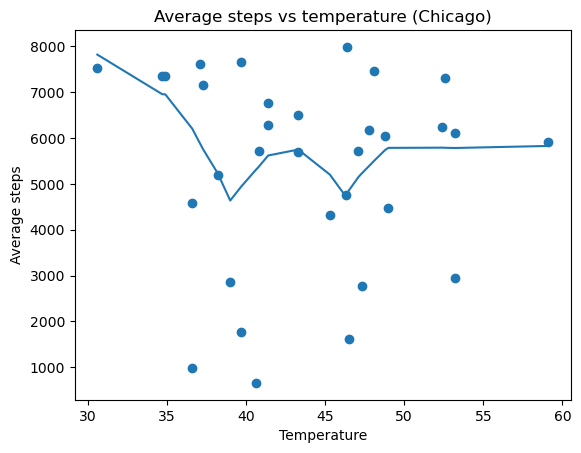

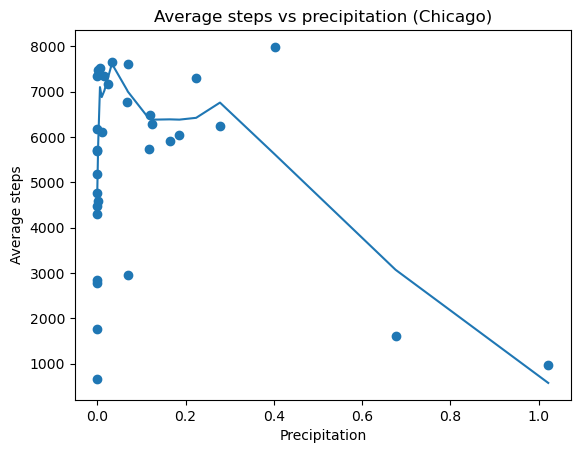

/var/folders/b1/lvlh1wcs52jf59_w02y338km0000gn/T/ipykernel_96886/858442259.py:95: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



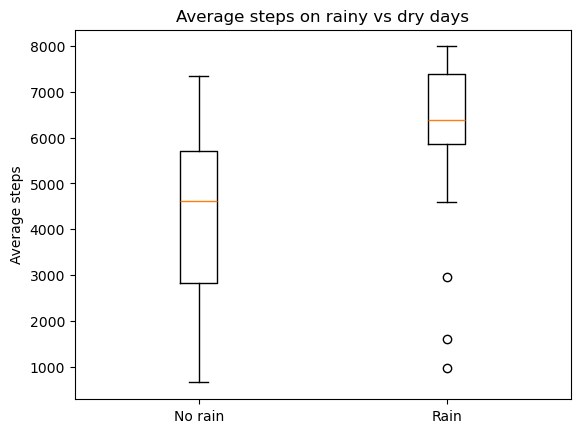

/var/folders/b1/lvlh1wcs52jf59_w02y338km0000gn/T/ipykernel_96886/858442259.py:102: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



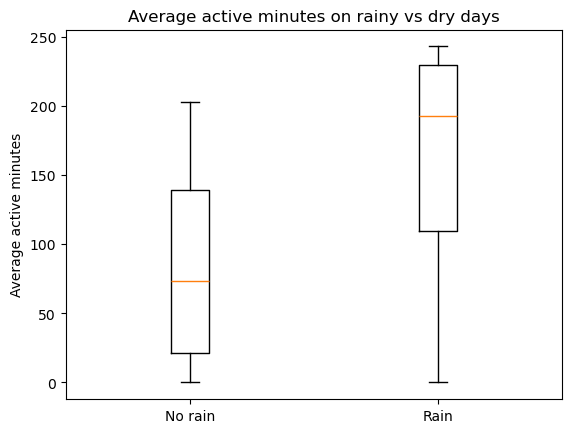

                            OLS Regression Results                            
Dep. Variable:              avg_steps   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     1.562
Date:                Fri, 20 Feb 2026   Prob (F-statistic):              0.227
Time:                        14:49:50   Log-Likelihood:                -288.27
No. Observations:                  32   AIC:                             582.5
Df Residuals:                      29   BIC:                             586.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5815.7883   2506.096      2.321      0.0

In [13]:
import pandas as pd

weather = pd.read_csv("chicago_weather.csv")  # change name if yours differs
print(weather.head())
print("Weather columns:", list(weather.columns))

# VisualCrossing typically: 'datetime' column for date (YYYY-MM-DD)
if "datetime" in weather.columns:
    weather["date"] = pd.to_datetime(weather["datetime"])
elif "date" in weather.columns:
    weather["date"] = pd.to_datetime(weather["date"])
else:
    raise ValueError("Can't find a date column in weather CSV (expected 'datetime' or 'date').")

# pick available temperature/precip columns (adjust if needed)
needed = ["date"]
for col in ["temp", "precip", "tempmax", "tempmin"]:
    if col in weather.columns:
        needed.append(col)

weather = weather[needed].copy()
print(weather.head())

daily = pd.read_sql("""
SELECT
  ActivityDate,
  TotalSteps,
  VeryActiveMinutes,
  FairlyActiveMinutes,
  LightlyActiveMinutes
FROM daily_activity;
""", con)

daily["date"] = pd.to_datetime(daily["ActivityDate"], format="%m/%d/%Y")

daily["total_active_minutes"] = (
    daily["VeryActiveMinutes"] + daily["FairlyActiveMinutes"] + daily["LightlyActiveMinutes"]
)

daily_summary = (daily.groupby("date", as_index=False)
                 .agg(avg_steps=("TotalSteps", "mean"),
                      avg_active_minutes=("total_active_minutes", "mean")))
print(daily_summary.head())
print("Fitbit dates:", daily_summary["date"].min(), "to", daily_summary["date"].max())

df = pd.merge(daily_summary, weather, on="date", how="inner")


df["temp_centered"] = df["temp"] - df["temp"].mean()
df["temp2"] = df["temp_centered"]**2

import numpy as np
df["log_precip"] = np.log1p(df["precip"])

df["weekday"] = df["date"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

print(df.head())
print("Merged rows:", len(df))

import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

if "temp" in df.columns:
    x = df["temp"].to_numpy()
    y = df["avg_steps"].to_numpy()

    plt.scatter(x, y)
    smoothed = lowess(y, x, frac=0.4, return_sorted=True)
    plt.plot(smoothed[:, 0], smoothed[:, 1])
    plt.title("Average steps vs temperature (Chicago)")
    plt.xlabel("Temperature")
    plt.ylabel("Average steps")
    plt.show()
else:
    print("No 'temp' column found in weather data.")

if "precip" in df.columns:
    x = df["precip"].to_numpy()
    y = df["avg_steps"].to_numpy()

    plt.scatter(x, y)
    smoothed = lowess(y, x, frac=0.5, return_sorted=True)
    plt.plot(smoothed[:, 0], smoothed[:, 1])
    plt.title("Average steps vs precipitation (Chicago)")
    plt.xlabel("Precipitation")
    plt.ylabel("Average steps")
    plt.show()
else:
    print("No 'precip' column found in weather data.")

if "precip" in df.columns:
    df["rainy_day"] = (df["precip"] > 0).astype(int)

    plt.boxplot([df.loc[df["rainy_day"]==0, "avg_steps"],
                 df.loc[df["rainy_day"]==1, "avg_steps"]],
                labels=["No rain", "Rain"])
    plt.title("Average steps on rainy vs dry days")
    plt.ylabel("Average steps")
    plt.show()

    plt.boxplot([df.loc[df["rainy_day"]==0, "avg_active_minutes"],
                 df.loc[df["rainy_day"]==1, "avg_active_minutes"]],
                labels=["No rain", "Rain"])
    plt.title("Average active minutes on rainy vs dry days")
    plt.ylabel("Average active minutes")
    plt.show()

import statsmodels.api as sm

cols = [c for c in ["temp", "precip"] if c in df.columns]
X = sm.add_constant(df[cols])
y = df["avg_steps"]

model = sm.OLS(y, X).fit()
print(model.summary())

if "temp" in df.columns:
    df["temp2"] = df["temp"]**2
    cols = [c for c in ["temp", "temp2", "precip"] if c in df.columns]
    X = sm.add_constant(df[cols])
    model2 = sm.OLS(df["avg_steps"], X).fit()
    print(model2.summary())

In [ ]:
# temperature has no signifcant linear effect and no clear trend in relation to step months
#  rain tends to reduce steps. it also has more variablility tho. 
# quality of the model: wather doesnt really explain much of the variation in activity 

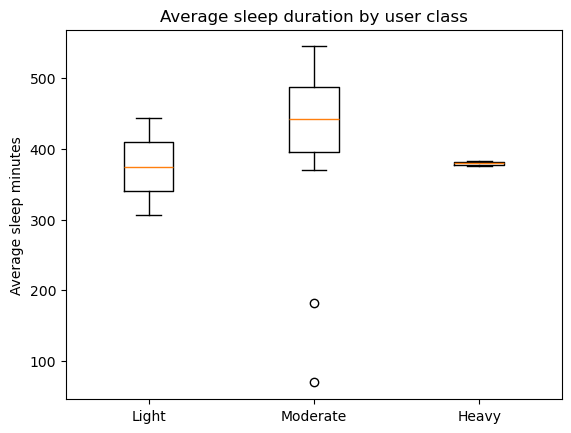

                            OLS Regression Results                            
Dep. Variable:         sleep_next_day   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9884
Date:                Fri, 20 Feb 2026   Prob (F-statistic):              0.321
Time:                        15:16:16   Log-Likelihood:                -1149.0
No. Observations:                 179   AIC:                             2302.
Df Residuals:                     177   BIC:                             2308.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  465.6019 

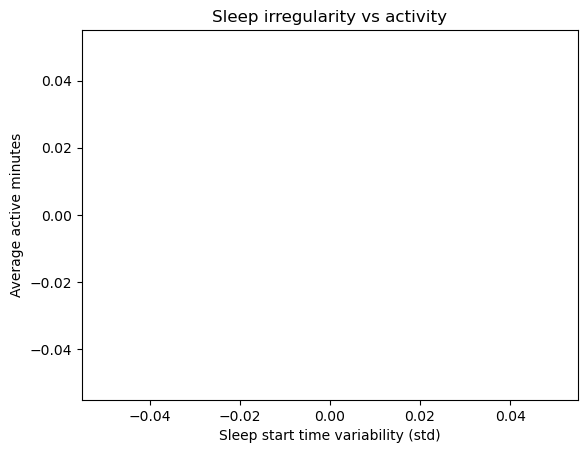

KeyError: "['sleep_minutes'] not in index"

In [17]:
# other interesting analyses 
# A) do heavy users sleep less?
# 1) Rebuild daily with Id
daily = pd.read_sql("""
SELECT
  Id,
  ActivityDate,
  TotalSteps,
  VeryActiveMinutes,
  FairlyActiveMinutes,
  LightlyActiveMinutes,
  SedentaryMinutes
FROM daily_activity;
""", con)

daily["date"] = pd.to_datetime(daily["ActivityDate"], format="%m/%d/%Y")
daily["total_active_minutes"] = (
    daily["VeryActiveMinutes"] + daily["FairlyActiveMinutes"] + daily["LightlyActiveMinutes"]
)

sleep_by_day["date"] = pd.to_datetime(sleep_by_day["date"])
# 2) Merge sleep minutes per day (sleep_by_day must already exist from earlier)
daily_sleep = daily.merge(sleep_by_day, on=["Id", "date"], how="inner")

# 3) NOW paste this (heavy users sleep less?)
df_user = daily_sleep.groupby("Id").agg(
    avg_steps=("TotalSteps","mean"),
    avg_active=("total_active_minutes","mean"),
    avg_sleep=("sleep_minutes","mean")
).reset_index()

df_user = df_user.merge(df_class, on="Id")

df_user.head()


import matplotlib.pyplot as plt

plt.boxplot([
    df_user[df_user["Class"]=="Light User"]["avg_sleep"],
    df_user[df_user["Class"]=="Moderate User"]["avg_sleep"],
    df_user[df_user["Class"]=="Heavy User"]["avg_sleep"]
], tick_labels=["Light", "Moderate", "Heavy"])

plt.title("Average sleep duration by user class")
plt.ylabel("Average sleep minutes")
plt.show()

# B) Does activity improve the following day's sleep?
df_lag = daily_sleep.sort_values(["Id", "date"]).copy()

df_lag["sleep_next_day"] = df_lag.groupby("Id")["sleep_minutes"].shift(-1)

import statsmodels.api as sm

X = sm.add_constant(df_lag["total_active_minutes"])
y = df_lag["sleep_next_day"]

model = sm.OLS(y.dropna(), X.loc[y.notna()]).fit()
print(model.summary())

# C) Heart rate? 
#D) Do irregular sleepers have lower activity?

import pandas as pd

sleep = pd.read_sql("""
WITH ms AS (
  SELECT
    CAST(Id AS INTEGER) AS Id,
    logId,
    datetime(date) AS t
  FROM minute_sleep
),
rng AS (
  SELECT
    Id,
    logId,
    MIN(t) AS start_time,
    MAX(t) AS end_time,
    (julianday(MAX(t)) - julianday(MIN(t))) * 24 * 60 + 1 AS sleep_minutes
  FROM ms
  GROUP BY Id, logId
)
SELECT * FROM rng
ORDER BY Id, start_time;
""", con)

print(sleep.head())
print("Rows:", len(sleep))

sleep["start_hour"] = pd.to_datetime(sleep["start_time"]).dt.hour

sleep_var = sleep.groupby("Id").agg(
    sleep_start_std=("start_hour","std")
).reset_index()

activity_mean = daily.groupby("Id").agg(
    avg_active=("total_active_minutes","mean")
).reset_index()

df_irregular = sleep_var.merge(activity_mean, on="Id")

plt.scatter(df_irregular["sleep_start_std"], df_irregular["avg_active"])
plt.xlabel("Sleep start time variability (std)")
plt.ylabel("Average active minutes")
plt.title("Sleep irregularity vs activity")
plt.show()

# E) correlation network

import seaborn as sns

corr_df = daily[[
    "TotalSteps",
    "total_active_minutes",
    "sleep_minutes",
    "SedentaryMinutes"
]].corr()

sns.heatmap(corr_df, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# F) Do people with high variability in activity sleep worse? Does consistency matter?

df_user_var = daily.groupby("Id").agg(
    steps_std=("TotalSteps","std"),
    sleep_std=("sleep_minutes","std")
)

plt.scatter(df_user_var["steps_std"], df_user_var["sleep_std"])
plt.xlabel("Steps variability")
plt.ylabel("Sleep variability")
plt.title("Activity variability vs Sleep variability")
plt.show()

# G) Does weather effect differ on weekends?

df["rain_weekend"] = df["precip"] * df["is_weekend"]

X = sm.add_constant(df[["precip","is_weekend","rain_weekend"]])
model = sm.OLS(df["avg_steps"], X).fit()
print(model.summary())

# H) Sleep → next-day activity, Activity → next-day sleep, Sedentary → heart rate

# I) daily avg steps and sleep over time

df["time_index"] = range(len(df))

df_time = daily.groupby("date").agg(
    avg_steps=("TotalSteps","mean"),
    avg_sleep=("sleep_minutes","mean")
).reset_index()

df_time["time_index"] = range(len(df_time))

X = sm.add_constant(df_time["time_index"])
model = sm.OLS(df_time["avg_steps"], X).fit()
print(model.summary())

In [12]:
print(daily.columns)

Index(['ActivityDate', 'TotalSteps', 'VeryActiveMinutes',
       'FairlyActiveMinutes', 'LightlyActiveMinutes', 'date',
       'total_active_minutes'],
      dtype='object')
